In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns

In [ ]:
df=pd.read_csv(r"C:\Users\LENOVO\Downloads\train.csv")

In [3]:
df.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [4]:
df.shape

(1460, 81)

In [5]:
df_null_clm=df.isnull().sum()/df.shape[0]*100

In [6]:
df_null_clm[df.isnull().sum()/df.shape[0]*100 >20]

Alley          93.767123
MasVnrType     59.726027
FireplaceQu    47.260274
PoolQC         99.520548
Fence          80.753425
MiscFeature    96.301370
dtype: float64

In [ ]:
null_clm_list=df_null_clm[df_null_clm>20].index

In [8]:
null_clm_list

Index(['Alley', 'MasVnrType', 'FireplaceQu', 'PoolQC', 'Fence', 'MiscFeature'], dtype='object')

In [9]:
df_drop_clm=df.drop(columns=null_clm_list)

In [10]:
df_drop_clm.isnull().sum()

Id                 0
MSSubClass         0
MSZoning           0
LotFrontage      259
LotArea            0
                ... 
MoSold             0
YrSold             0
SaleType           0
SaleCondition      0
SalePrice          0
Length: 75, dtype: int64

In [11]:
df_cat_clm=df_drop_clm.select_dtypes(include=['object'])

In [12]:
df_num_clm=df_drop_clm.select_dtypes(include=['int', 'float'])

# Handling num col

In [ ]:
a=df_num_clm.isnull().sum()[df_num_clm.isnull().sum() > 0].index

In [ ]:
for i in a:
    if i in df_num_clm.columns:
        df_num_clm[i].replace(np.nan, df_num_clm[i].mode()[0], inplace=True)

/var/folders/9d/x9v4fczs01xdjhbh4msz_f_c0000gn/T/ipykernel_2166/3947200074.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_num_clm[i].replace(np.nan, df_num_clm[i].mode()[0], inplace=True)


In [14]:
df_num_clm.isnull().sum()

Id               0
MSSubClass       0
LotFrontage      0
LotArea          0
OverallQual      0
OverallCond      0
YearBuilt        0
YearRemodAdd     0
MasVnrArea       0
BsmtFinSF1       0
BsmtFinSF2       0
BsmtUnfSF        0
TotalBsmtSF      0
1stFlrSF         0
2ndFlrSF         0
LowQualFinSF     0
GrLivArea        0
BsmtFullBath     0
BsmtHalfBath     0
FullBath         0
HalfBath         0
BedroomAbvGr     0
KitchenAbvGr     0
TotRmsAbvGrd     0
Fireplaces       0
GarageYrBlt      0
GarageCars       0
GarageArea       0
WoodDeckSF       0
OpenPorchSF      0
EnclosedPorch    0
3SsnPorch        0
ScreenPorch      0
PoolArea         0
MiscVal          0
MoSold           0
YrSold           0
SalePrice        0
dtype: int64

# Handling cat col

In [ ]:
b=df_cat_clm.isnull().sum()[df_cat_clm.isnull().sum() > 0].index

In [ ]:
for i in b:
    if i in df_cat_clm.columns:
        df_cat_clm[i].replace(np.nan, df_cat_clm[i].mode()[0], inplace=True)

/var/folders/9d/x9v4fczs01xdjhbh4msz_f_c0000gn/T/ipykernel_2166/690968023.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_cat_clm[i].replace(np.nan, df_cat_clm[i].mode()[0], inplace=True)


In [16]:
df_cat_clm.isnull().sum()

MSZoning         0
Street           0
LotShape         0
LandContour      0
Utilities        0
LotConfig        0
LandSlope        0
Neighborhood     0
Condition1       0
Condition2       0
BldgType         0
HouseStyle       0
RoofStyle        0
RoofMatl         0
Exterior1st      0
Exterior2nd      0
ExterQual        0
ExterCond        0
Foundation       0
BsmtQual         0
BsmtCond         0
BsmtExposure     0
BsmtFinType1     0
BsmtFinType2     0
Heating          0
HeatingQC        0
CentralAir       0
Electrical       0
KitchenQual      0
Functional       0
GarageType       0
GarageFinish     0
GarageQual       0
GarageCond       0
PavedDrive       0
SaleType         0
SaleCondition    0
dtype: int64

In [17]:
cat_col=df_cat_clm.columns

In [18]:
cat_col

Index(['MSZoning', 'Street', 'LotShape', 'LandContour', 'Utilities',
       'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1', 'Condition2',
       'BldgType', 'HouseStyle', 'RoofStyle', 'RoofMatl', 'Exterior1st',
       'Exterior2nd', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual',
       'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2', 'Heating',
       'HeatingQC', 'CentralAir', 'Electrical', 'KitchenQual', 'Functional',
       'GarageType', 'GarageFinish', 'GarageQual', 'GarageCond', 'PavedDrive',
       'SaleType', 'SaleCondition'],
      dtype='object')

In [19]:
from sklearn.preprocessing import OneHotEncoder

In [20]:
ohe=OneHotEncoder(sparse_output=False)

In [21]:
for i in cat_col:
    df_cat_clm=pd.get_dummies(df_cat_clm,columns=[i],drop_first=True,dtype=int)

In [22]:
df_cat_clm.shape

(1460, 193)

# Concat both cat and num cols

In [23]:
df2=pd.concat([df_cat_clm,df_num_clm], axis=1)

In [ ]:
from sklearn.model_selection import train_test_split

In [ ]:
X=df2.drop(columns=['SalePrice'])
y=df2['SalePrice']

In [ ]:
X_train,X_test, y_train, y_test=train_test_split(X,y,test_size=.2, random_state=12)

In [ ]:
from sklearn.preprocessing import StandardScaler

In [ ]:
ss=StandardScaler()

In [ ]:
arr=ss.fit_transform(X)
df2_scale=pd.DataFrame(arr)
df3_scale=pd.DataFrame(df2_scale,columns=cat_col)

In [27]:
df2.shape

(1460, 231)

In [28]:
from sklearn.linear_model import LinearRegression

In [29]:
lr=LinearRegression()

In [30]:
lr.fit(X_train,y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [31]:
y_pred=lr.predict(X_test) 

In [32]:
import matplotlib.pyplot as plt

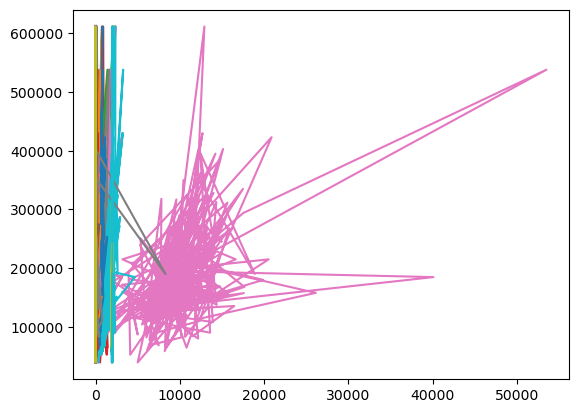

In [33]:
plt.plot(X_test,y_test)
plt.show()

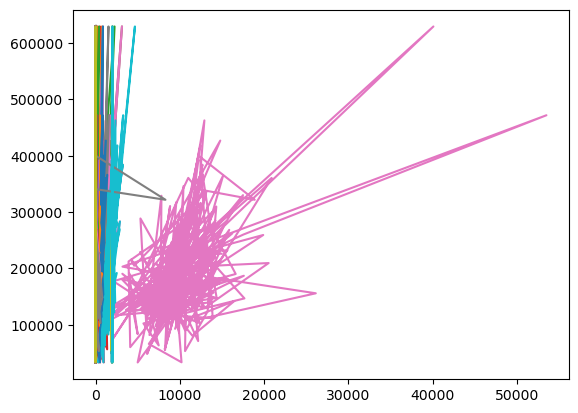

In [34]:
plt.plot(X_test,y_pred)
plt.show()

In [35]:
lr.score(X_test,y_test) 

0.7869918770894615